# 03 - Secuencias de proteina y propiedades

Comparacion de las proteinas de cada paciente contra la referencia sintetica, clasificacion del
tipo de cambio, conexion con las variantes de DNA del notebook 02 y calculo de propiedades simples.

**Preguntas que responde este notebook:** que cambios aminoacidicos aparecen, cuales de las
variantes de DNA se traducen en un cambio de proteina, y si las propiedades proteicas se
distribuyen distinto entre sanos y pacientes con Alzheimer.

**Salidas principales**
- `results/tables/cambios_proteicos_largo.csv` - un evento por fila
- `results/tables/clasificacion_proteinas.csv` - tipo de cambio por paciente y proteina
- `results/tables/dna_a_proteina.csv` - efecto proteico de cada variante de DNA recurrente
- `results/tables/propiedades_proteicas.csv` - descriptores por secuencia
- `results/tables/proteina_para_integracion.csv` - insumo del notebook 04

> Requiere haber ejecutado el notebook 02, que genera `variantes_largo.csv`.
> Datos **sinteticos** de uso docente.


## 0. Configuracion y rutas

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)

sns.set_theme(style="whitegrid", context="notebook")
PALETA = {"Sano": "#4C72B0", "Alzheimer": "#DD8452"}

GENES = ["APP", "PSEN1", "PSEN2", "APOE", "TREM2"]

Ajusta `DIR_PROYECTO` a la carpeta de tu proyecto. Los archivos se buscan dentro de ella,
sin importar en que subcarpeta esten.

In [2]:
# notebooks/ -> raiz del proyecto. Funciona igual para cualquiera que abra
# el notebook desde notebooks/, sin escribir una ruta propia.
DIR_PROYECTO = Path.cwd().parent

rutas = {
    "proteinas": DIR_PROYECTO / "raw_data" / "proteins" / "alzheimer_synthetic_1000_patients_5proteins_clean.fasta",
    "referencia": DIR_PROYECTO / "raw_data" / "proteins" / "alzheimer_synthetic_reference_5proteins_clean.fasta",
    "clinico": DIR_PROYECTO / "raw_data" / "ficha_clinica" / "synthetic_alzheimer_patients_1000.csv",
}
for clave, ruta in rutas.items():
    print(f"{clave:<12} {'OK   ' if ruta.exists() else 'FALTA'} {ruta}")

if any(v is None for v in rutas.values()):
    raise FileNotFoundError("Falta algun archivo. Revisa DIR_PROYECTO.")

DIR_RESULTADOS = DIR_PROYECTO / "results"
DIR_FIGURAS    = DIR_RESULTADOS / "figures"
DIR_TABLAS     = DIR_RESULTADOS / "tables"
(DIR_FIGURAS / "proteinas").mkdir(parents=True, exist_ok=True)
DIR_TABLAS.mkdir(parents=True, exist_ok=True)


def guardar_figura(nombre, subcarpeta="proteinas"):
    ruta = DIR_FIGURAS / subcarpeta / f"{nombre}.png"
    plt.savefig(ruta, dpi=300, bbox_inches="tight")
    return ruta


def guardar_tabla(df, nombre, index=False):
    ruta = DIR_TABLAS / f"{nombre}.csv"
    df.to_csv(ruta, index=index)
    return ruta


print("\nResultados en:", DIR_RESULTADOS)

proteinas    OK    /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/raw_data/proteins/alzheimer_synthetic_1000_patients_5proteins_clean.fasta
referencia   OK    /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/raw_data/proteins/alzheimer_synthetic_reference_5proteins_clean.fasta
clinico      OK    /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/raw_data/ficha_clinica/synthetic_alzheimer_patients_1000.csv

Resultados en: /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/results


---
## 1. Lectura de las secuencias

Se usa el FASTA **clean**, en el que los codones de parada internos aparecen como `X` en vez de
`*`. La documentacion del dataset lo recomienda porque los fragmentos sinteticos no son secuencias
codificantes canonicas y la traduccion literal produce paradas internas.

In [3]:
def leer_fasta(ruta):
    """Devuelve {encabezado: secuencia} desde un archivo FASTA."""
    secuencias, encabezado, partes = {}, None, []
    with open(ruta, "r", encoding="utf-8") as f:
        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            if linea.startswith(">"):
                if encabezado is not None:
                    secuencias[encabezado] = "".join(partes)
                encabezado, partes = linea[1:].strip(), []
            else:
                partes.append(linea.upper())
    if encabezado is not None:
        secuencias[encabezado] = "".join(partes)
    return secuencias


def parsear_encabezado(encabezado):
    campos = encabezado.split("|")
    info = {"id": campos[0].strip()}
    for campo in campos[1:]:
        if "=" in campo:
            clave, valor = campo.split("=", 1)
            info[clave.strip()] = valor.strip()
    return info


fasta_prot = leer_fasta(rutas["proteinas"])
fasta_ref  = leer_fasta(rutas["referencia"])

referencias = {parsear_encabezado(k)["gene"]: v for k, v in fasta_ref.items()}

filas = []
for encabezado, secuencia in fasta_prot.items():
    info = parsear_encabezado(encabezado)
    filas.append({"patient_id": info["id"], "gene": info["gene"],
                  "secuencia": secuencia, "largo": len(secuencia)})

proteinas = pd.DataFrame(filas)

print("Registros:", len(proteinas), "| Pacientes:", proteinas["patient_id"].nunique())
print("\nLongitud de la referencia por proteina:")
for gen in GENES:
    print(f"   {gen:<7} {len(referencias[gen])} aa")

Registros: 5000 | Pacientes: 1000

Longitud de la referencia por proteina:
   APP     300 aa
   PSEN1   260 aa
   PSEN2   250 aa
   APOE    200 aa
   TREM2   240 aa


---
## 2. Control de calidad

Dos cosas que revisar antes de comparar: que el alfabeto sea de aminoacidos validos, y cuantas
posiciones `X` hay. Los `X` obligan a definir una regla, porque no se sabe que aminoacido
representan.

In [4]:
clinica = pd.read_csv(rutas["clinico"], usecols=["patient_id", "alzheimer"])
clinica["diagnostico"] = clinica["alzheimer"].map({0: "Sano", 1: "Alzheimer"})

ids_prot = set(proteinas["patient_id"])
ids_csv  = set(clinica["patient_id"])
print(f"IDs que coinciden con la ficha clinica: {len(ids_prot & ids_csv)} de {len(ids_csv)}")
print("Proteinas por paciente (deben ser 5):",
      proteinas.groupby("patient_id")["gene"].nunique().unique())

alfabeto = sorted({c for s in proteinas["secuencia"] for c in set(s)})
print("\nAlfabeto observado:", "".join(alfabeto))

proteinas["n_X"] = proteinas["secuencia"].str.count("X")
proteinas["frac_X"] = proteinas["n_X"] / proteinas["largo"]

print(f"Residuos X totales: {proteinas['n_X'].sum()} "
      f"({proteinas['n_X'].sum() / proteinas['largo'].sum() * 100:.1f}% de todos los residuos)")
print("X presentes tambien en la referencia:",
      {g: referencias[g].count("X") for g in GENES})

IDs que coinciden con la ficha clinica: 1000 de 1000
Proteinas por paciente (deben ser 5): [5]

Alfabeto observado: ACDEFGHIKLMNPQRSTVWXY
Residuos X totales: 40358 (3.2% de todos los residuos)
X presentes tambien en la referencia: {'APP': 8, 'PSEN1': 9, 'PSEN2': 13, 'APOE': 4, 'TREM2': 6}


**Regla adoptada para los X.** Se aplica la misma a todos los pacientes: los `X` **se excluyen
del denominador** al calcular composiciones y propiedades, y ademas se reporta `frac_X` como
descriptor propio. Asi ninguna propiedad queda inflada o diluida por posiciones ambiguas, y la
cantidad de ambiguedad sigue siendo visible y comparable entre grupos.

La referencia tambien contiene X, de modo que su presencia no es en si un cambio del paciente.

---
## 3. Comparacion contra la referencia

Se usa la misma logica del notebook 02, adaptada a aminoacidos. Un detalle importante: en
proteinas, un cambio de una sola base en el DNA puede producir **ningun** cambio (sinonimo) o un
cambio de un aminoacido (missense); en cambio una insercion o delecion de 1 o 2 nucleotidos
corre el marco de lectura y altera **toda la secuencia posterior**.

In [5]:
def comparar_secuencias(ref, alt):
    """Compara una secuencia contra su referencia. Devuelve lista de eventos."""
    a = np.frombuffer(ref.encode(), dtype="S1")
    b = np.frombuffer(alt.encode(), dtype="S1")
    n, m = len(a), len(b)

    if n == m:
        idx = np.flatnonzero(a != b)
        return [{"posicion": int(i) + 1, "ref": ref[i], "alt": alt[i], "tipo": "sustitucion"}
                for i in idx]

    d = n - m
    largo, corto, ldel = (a, b, d) if d > 0 else (b, a, -d)
    L = len(corto)

    pre = np.concatenate(([0], np.cumsum(largo[:L] != corto)))
    dif_suf = (largo[ldel:] != corto)
    suf = np.concatenate((np.cumsum(dif_suf[::-1])[::-1], [0]))
    k = int(np.argmin(pre + suf))

    eventos = []
    if d > 0:
        eventos.append({"posicion": k + 1, "ref": ref[k:k + ldel], "alt": "-",
                        "tipo": "delecion"})
    else:
        eventos.append({"posicion": k + 1, "ref": "-", "alt": alt[k:k + ldel],
                        "tipo": "insercion"})

    for i in np.flatnonzero(largo[:k] != corto[:k]):
        i = int(i)
        eventos.append({"posicion": i + 1, "ref": ref[i], "alt": alt[i], "tipo": "sustitucion"})
    for j in np.flatnonzero(largo[k + ldel:] != corto[k:]):
        j = int(j) + k
        pr, pa = (j + ldel, j) if d > 0 else (j, j + ldel)
        eventos.append({"posicion": pr + 1, "ref": ref[pr], "alt": alt[pa],
                        "tipo": "sustitucion"})

    return sorted(eventos, key=lambda e: e["posicion"])


registros = []
for fila in proteinas.itertuples(index=False):
    for evento in comparar_secuencias(referencias[fila.gene], fila.secuencia):
        registros.append({"patient_id": fila.patient_id, "gene": fila.gene, **evento})

cambios = pd.DataFrame(registros)
cambios["cambio_id"] = (cambios["gene"] + ":p." + cambios["ref"]
                        + cambios["posicion"].astype(str) + cambios["alt"])

print(f"Eventos detectados: {len(cambios)}")
display(cambios["tipo"].value_counts().rename("n"))

guardar_tabla(cambios, "cambios_proteicos_largo")
cambios.head(10)

Eventos detectados: 28655


tipo
sustitucion    28351
delecion         218
insercion         86
Name: n, dtype: int64

,patient_id,gene,posicion,ref,alt,tipo,cambio_id
0,P0001,PSEN1,170,F,L,sustitucion,PSEN1:p.F170L
1,P0001,PSEN2,136,S,I,sustitucion,PSEN2:p.S136I
2,P0001,PSEN2,137,F,S,sustitucion,PSEN2:p.F137S
3,P0001,PSEN2,138,P,X,sustitucion,PSEN2:p.P138X
4,P0001,PSEN2,139,E,D,sustitucion,PSEN2:p.E139D
5,P0001,PSEN2,140,T,C,sustitucion,PSEN2:p.T140C
6,P0001,PSEN2,142,P,L,sustitucion,PSEN2:p.P142L
7,P0001,PSEN2,143,W,E,sustitucion,PSEN2:p.W143E
8,P0001,PSEN2,144,R,T,sustitucion,PSEN2:p.R144T
9,P0001,PSEN2,146,X,V,sustitucion,PSEN2:p.X146V


---
## 4. Clasificacion del tipo de cambio por secuencia

No todos los cambios son equivalentes. Una proteina con dos sustituciones puntuales es muy
distinta de una con la mitad de su secuencia alterada. La clasificacion usa dos senales: cuantos
residuos cambiaron y si cambio la longitud.

In [6]:
UMBRAL_EXTENSO = 0.10   # fraccion de residuos alterados para considerar un cambio extenso

resumen_sec = (cambios.groupby(["patient_id", "gene"])
               .agg(n_eventos=("posicion", "size"),
                    n_sustituciones=("tipo", lambda s: (s == "sustitucion").sum()),
                    n_indels=("tipo", lambda s: s.isin(["insercion", "delecion"]).sum()))
               .reset_index())

clasificacion = proteinas[["patient_id", "gene", "largo", "n_X", "frac_X"]].merge(
    resumen_sec, on=["patient_id", "gene"], how="left").fillna({"n_eventos": 0,
                                                               "n_sustituciones": 0,
                                                               "n_indels": 0})
clasificacion[["n_eventos", "n_sustituciones", "n_indels"]] = \
    clasificacion[["n_eventos", "n_sustituciones", "n_indels"]].astype(int)

clasificacion["largo_ref"] = clasificacion["gene"].map({g: len(s) for g, s in referencias.items()})
clasificacion["delta_largo"] = clasificacion["largo"] - clasificacion["largo_ref"]
clasificacion["frac_alterada"] = clasificacion["n_sustituciones"] / clasificacion["largo_ref"]


def clasificar(fila):
    if fila["n_eventos"] == 0:
        return "sin cambio"
    if fila["frac_alterada"] >= UMBRAL_EXTENSO:
        return "cambio extenso (compatible con frameshift)"
    if fila["n_indels"] > 0:
        return "indel in-frame"
    return "sustituciones puntuales"


clasificacion["clase"] = clasificacion.apply(clasificar, axis=1)
clasificacion = clasificacion.merge(clinica, on="patient_id")

guardar_tabla(clasificacion, "clasificacion_proteinas")

print("Clasificacion de las 5.000 secuencias:")
display(clasificacion["clase"].value_counts().rename("n_secuencias"))

print("\nPor proteina:")
display(pd.crosstab(clasificacion["gene"], clasificacion["clase"]).reindex(GENES))

Clasificacion de las 5.000 secuencias:


clase
sin cambio                                    2362
sustituciones puntuales                       2231
cambio extenso (compatible con frameshift)     231
indel in-frame                                 176
Name: n_secuencias, dtype: int64


Por proteina:


clase,cambio extenso (compatible con frameshift),indel in-frame,sin cambio,sustituciones puntuales
gene,,,,
APP,35,58,478,429
PSEN1,27,60,463,450
PSEN2,78,17,523,382
APOE,36,22,387,555
TREM2,55,19,511,415


diagnostico,Alzheimer,Sano
clase,,
cambio extenso (compatible con frameshift),6.3,3.7
indel in-frame,5.5,2.5
sin cambio,33.5,54.4
sustituciones puntuales,54.7,39.4


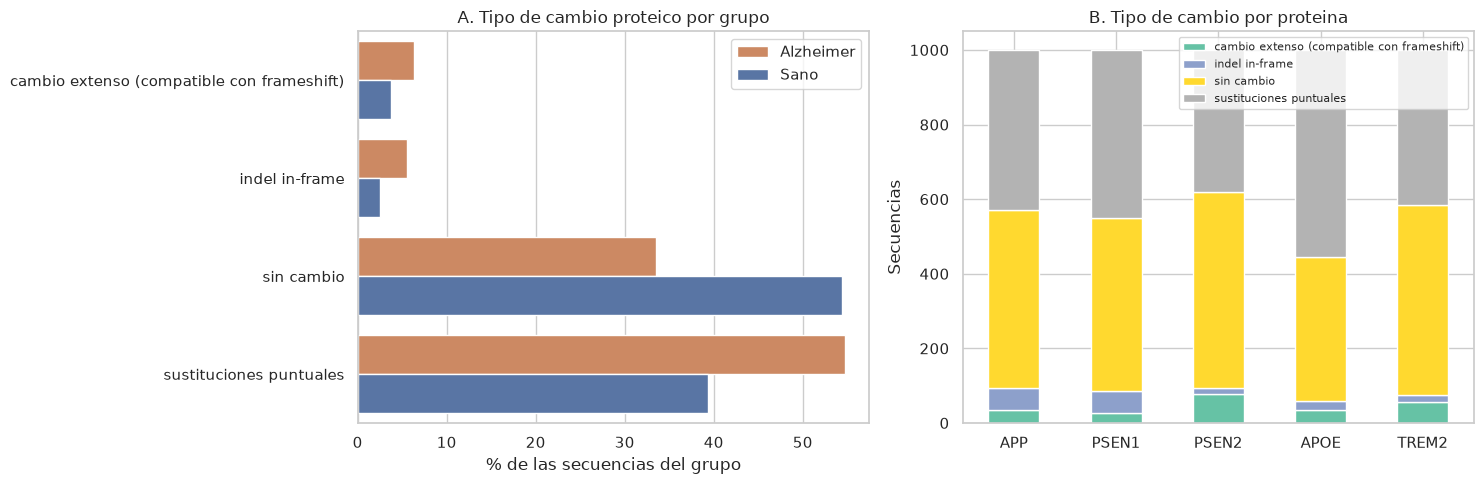

In [7]:
# Reparto de clases entre grupos, en porcentaje de pacientes de cada grupo
tabla_clase = (pd.crosstab(clasificacion["clase"], clasificacion["diagnostico"],
                           normalize="columns") * 100).round(1)
display(tabla_clase)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

datos = tabla_clase.reset_index().melt(id_vars="clase", var_name="grupo", value_name="pct")
sns.barplot(data=datos, y="clase", x="pct", hue="grupo", palette=PALETA, ax=ax[0])
ax[0].set(title="A. Tipo de cambio proteico por grupo",
          xlabel="% de las secuencias del grupo", ylabel="")
ax[0].legend(title="")

conteo = (clasificacion.groupby(["gene", "clase"]).size().unstack(fill_value=0)
          .reindex(GENES))
conteo.plot(kind="bar", stacked=True, ax=ax[1], colormap="Set2")
ax[1].set(title="B. Tipo de cambio por proteina", xlabel="", ylabel="Secuencias")
ax[1].tick_params(axis="x", rotation=0)
ax[1].legend(title="", fontsize=8)

plt.tight_layout()
guardar_figura("clases_de_cambio")
plt.show()

---
## 5. Conexion DNA a proteina

Esta es la seccion que la guia considera mas importante de este notebook: comprobar cuales de las
variantes de DNA detectadas en el notebook 02 producen un cambio en la proteina y cuales no.

La traduccion fue en marco 1 desde el nucleotido 1, asi que la posicion del aminoacido se obtiene
directamente de la posicion del nucleotido:

$$pos_{aa} = \left\lceil \frac{pos_{nt}}{3} \right\rceil$$

Para cada variante recurrente se compara que ocurre en esa posicion proteica en los pacientes
portadores frente a los no portadores. Si el aminoacido no cambia, la variante es **sinonima**.

In [8]:
ruta_variantes = DIR_TABLAS / "variantes_largo.csv"
if not ruta_variantes.exists():
    raise FileNotFoundError("Falta variantes_largo.csv. Ejecuta primero el notebook 02.")

variantes_dna = pd.read_csv(ruta_variantes)
frecuencias = pd.read_csv(DIR_TABLAS / "frecuencias_variantes.csv")

print("Variantes de DNA recurrentes a evaluar:", len(frecuencias))

# Secuencias proteicas indexadas para consulta rapida
seq_prot = {(f.patient_id, f.gene): f.secuencia for f in proteinas.itertuples(index=False)}

resultados = []
for fila in frecuencias.itertuples(index=False):
    gen = fila.gene
    pos_aa = int(np.ceil(fila.posicion / 3))
    ref_prot = referencias[gen]

    portadores = set(variantes_dna.loc[variantes_dna["variante_id"] == fila.variante_id,
                                       "patient_id"])
    todos = set(proteinas.loc[proteinas["gene"] == gen, "patient_id"])
    no_portadores = todos - portadores

    def aa_en(pacientes):
        vistos = {}
        for pid in pacientes:
            s = seq_prot.get((pid, gen), "")
            if len(s) >= pos_aa:
                aa = s[pos_aa - 1]
                vistos[aa] = vistos.get(aa, 0) + 1
        return vistos

    aa_port = aa_en(portadores)
    aa_no   = aa_en(no_portadores)

    aa_ref = ref_prot[pos_aa - 1] if len(ref_prot) >= pos_aa else "?"
    aa_mayoritario = max(aa_port, key=aa_port.get) if aa_port else "?"

    # Cambios extensos entre portadores: senal de frameshift
    clase_port = clasificacion[(clasificacion["gene"] == gen)
                               & (clasificacion["patient_id"].isin(portadores))]
    pct_extenso = (clase_port["clase"]
                   .eq("cambio extenso (compatible con frameshift)").mean() * 100)

    # el identificador tiene la forma GEN:posicion:ref>alt
    ref_nt, alt_nt = fila.variante_id.split(":")[2].split(">")

    if fila.tipo in ("insercion", "delecion"):
        largo_indel = len(ref_nt if fila.tipo == "delecion" else alt_nt)
        efecto = ("indel in-frame" if largo_indel % 3 == 0 else "frameshift")
    elif aa_mayoritario == aa_ref:
        efecto = "sinonimo"
    else:
        efecto = "missense"

    resultados.append({
        "variante_dna": fila.variante_id,
        "gene": gen,
        "pos_nt": fila.posicion,
        "pos_aa": pos_aa,
        "tipo_dna": fila.tipo,
        "cambio_nt": f"{ref_nt}>{alt_nt}",
        "aa_referencia": aa_ref,
        "aa_portadores": aa_mayoritario,
        "efecto_proteico": efecto,
        "pct_portadores_cambio_extenso": round(pct_extenso, 1),
        "pct_alzheimer": fila.pct_alzheimer,
        "pct_sano": fila.pct_sano,
        "diferencia_puntos": fila.diferencia_puntos,
    })

dna_a_proteina = pd.DataFrame(resultados)
guardar_tabla(dna_a_proteina, "dna_a_proteina")
dna_a_proteina

Variantes de DNA recurrentes a evaluar: 14


,variante_dna,gene,pos_nt,pos_aa,tipo_dna,cambio_nt,aa_referencia,aa_portadores,efecto_proteico,pct_portadores_cambio_extenso,pct_alzheimer,pct_sano,diferencia_puntos
0,APOE:205:T>G,APOE,205,69,SNP,T>G,C,G,missense,2.1,60.06,19.33,40.73
1,APOE:311:C>T,APOE,311,104,SNP,C>T,T,I,missense,2.1,60.06,19.33,40.73
2,PSEN1:133:C>A,PSEN1,133,45,SNP,C>A,H,N,missense,2.8,26.24,2.89,23.35
3,TREM2:251:C>A,TREM2,251,84,SNP,C>A,T,K,missense,4.7,19.24,2.89,16.35
4,APP:217:G>C,APP,217,73,SNP,G>C,A,P,missense,3.3,19.53,3.81,15.73
5,TREM2:529:C>A,TREM2,529,177,SNP,C>A,Q,K,missense,12.1,15.45,1.98,13.47
6,PSEN1:374:C>G,PSEN1,374,125,SNP,C>G,T,R,missense,4.1,15.74,2.89,12.85
7,PSEN2:615:T>G,PSEN2,615,205,SNP,T>G,N,K,missense,6.9,12.83,2.13,10.70
8,APP:452:C>G,APP,452,151,SNP,C>G,A,G,missense,1.4,13.70,3.35,10.35
9,PSEN2:166:T>C,PSEN2,166,56,SNP,T>C,S,P,missense,12.5,11.66,2.44,9.23


**Como leer esta tabla en la defensa.** Cada fila conecta una variante de DNA con su
consecuencia proteica:

- `sinonimo` - el nucleotido cambio pero el aminoácido no. Es el ejemplo mas claro de que un
  cambio en DNA no implica un cambio en la proteina.
- `missense` - cambio el aminoacido. `aa_referencia` y `aa_portadores` muestran cual por cual.
- `indel in-frame` - insercion o delecion de un multiplo de 3 nucleotidos: se agrega o se pierde
  un aminoacido completo, y el resto de la secuencia se mantiene.
- `frameshift` - insercion o delecion que no es multiplo de 3: corre el marco de lectura y altera
  toda la secuencia posterior. La columna `pct_portadores_cambio_extenso` lo confirma de forma
  independiente, contando cuantos portadores quedaron clasificados con cambio extenso.

---
## 6. Propiedades proteicas simples

La guia pide descriptores sencillos y facilmente interpretables: longitud, composicion,
fraccion hidrofobica, fraccion cargada, fraccion aromatica y una estimacion de carga o peso
molecular. Nada de estructura 3D ni modelos.

In [9]:
HIDROFOBICOS = set("AVILMFWC")
CARGADOS_POS = set("KR")
CARGADOS_NEG = set("DE")
AROMATICOS   = set("FWY")
POLARES      = set("STNQ")

# Peso molecular promedio de residuo (Da), aminoacidos estandar
PESOS = {"A": 71.08, "R": 156.19, "N": 114.10, "D": 115.09, "C": 103.14,
         "E": 129.12, "Q": 128.13, "G": 57.05, "H": 137.14, "I": 113.16,
         "L": 113.16, "K": 128.17, "M": 131.19, "F": 147.18, "P": 97.12,
         "S": 87.08, "T": 101.10, "V": 99.13, "W": 186.21, "Y": 163.18}


def propiedades(secuencia):
    """Descriptores simples. Los residuos X se excluyen del denominador."""
    validos = [c for c in secuencia if c != "X"]
    n = len(validos)
    if n == 0:
        return {}

    conteo = {c: validos.count(c) for c in set(validos)}
    n_pos = sum(conteo.get(c, 0) for c in CARGADOS_POS)
    n_neg = sum(conteo.get(c, 0) for c in CARGADOS_NEG)

    return {
        "largo": len(secuencia),
        "n_validos": n,
        "frac_hidrofobica": sum(conteo.get(c, 0) for c in HIDROFOBICOS) / n,
        "frac_cargada": (n_pos + n_neg) / n,
        "frac_aromatica": sum(conteo.get(c, 0) for c in AROMATICOS) / n,
        "frac_polar": sum(conteo.get(c, 0) for c in POLARES) / n,
        "carga_neta": n_pos - n_neg,
        "carga_neta_relativa": (n_pos - n_neg) / n,
        "peso_molecular_kda": (sum(PESOS.get(c, 0) for c in validos) + 18.02) / 1000,
    }


props = pd.DataFrame([{"patient_id": f.patient_id, "gene": f.gene,
                       "frac_X": f.frac_X, **propiedades(f.secuencia)}
                      for f in proteinas.itertuples(index=False)])

props = props.merge(clinica, on="patient_id")
guardar_tabla(props, "propiedades_proteicas")
props.head()

,patient_id,gene,frac_X,largo,n_validos,frac_hidrofobica,frac_cargada,frac_aromatica,frac_polar,carga_neta,carga_neta_relativa,peso_molecular_kda,alzheimer,diagnostico
0,P0001,APP,0.026667,300,292,0.332192,0.208904,0.041096,0.222603,27,0.092466,31.61528,1,Alzheimer
1,P0001,PSEN1,0.034615,260,251,0.306773,0.203187,0.079681,0.266932,7,0.027888,28.37611,1,Alzheimer
2,P0001,PSEN2,0.064257,249,233,0.377682,0.184549,0.081545,0.218884,11,0.047210,25.68331,1,Alzheimer
3,P0001,APOE,0.020000,200,196,0.306122,0.183673,0.035714,0.173469,16,0.081633,20.57442,1,Alzheimer
4,P0001,TREM2,0.025000,240,234,0.380342,0.196581,0.059829,0.217949,20,0.085470,25.73984,1,Alzheimer


In [10]:
DESCRIPTORES = ["largo", "frac_hidrofobica", "frac_cargada", "frac_aromatica",
                "frac_polar", "carga_neta", "peso_molecular_kda", "frac_X"]


def d_de_cohen(x, y):
    nx, ny = len(x), len(y)
    s = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    return (x.mean() - y.mean()) / s if s > 0 else 0.0


filas = []
for gen in GENES:
    sub = props[props["gene"] == gen]
    enf, san = sub[sub["alzheimer"] == 1], sub[sub["alzheimer"] == 0]
    for desc in DESCRIPTORES:
        filas.append({"gene": gen, "descriptor": desc,
                      "media_sano": san[desc].mean(),
                      "media_alzheimer": enf[desc].mean(),
                      "efecto_d": d_de_cohen(enf[desc], san[desc])})

efectos = pd.DataFrame(filas).round(4)
efectos = efectos.reindex(efectos["efecto_d"].abs().sort_values(ascending=False).index)

guardar_tabla(efectos, "efectos_propiedades_proteicas")
print("Descriptores con mayor diferencia entre grupos:")
efectos.head(12)

Descriptores con mayor diferencia entre grupos:


,gene,descriptor,media_sano,media_alzheimer,efecto_d
28,APOE,frac_polar,0.1727,0.1704,-0.6476
37,TREM2,carga_neta,20.9619,21.5627,0.4108
35,TREM2,frac_aromatica,0.0600,0.0610,0.3710
0,APP,largo,299.9650,299.8717,-0.3459
20,PSEN2,frac_polar,0.2314,0.2299,-0.3094
17,PSEN2,frac_hidrofobica,0.4001,0.3982,-0.3081
8,PSEN1,largo,260.0061,260.0845,0.2994
1,APP,frac_hidrofobica,0.3320,0.3311,-0.2952
34,TREM2,frac_cargada,0.2009,0.2020,0.2699
38,TREM2,peso_molecular_kda,25.7865,25.8172,0.2528


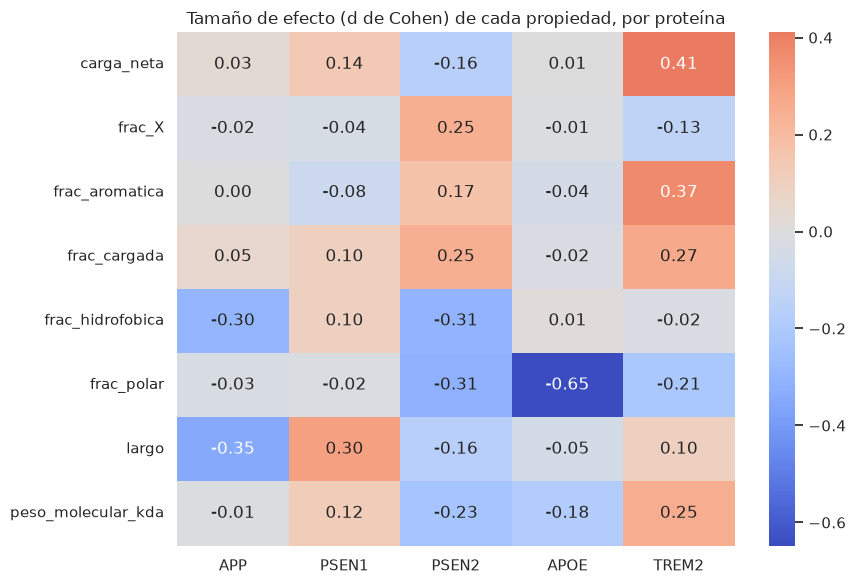

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
pivote = efectos.pivot(index="descriptor", columns="gene", values="efecto_d")[GENES]
sns.heatmap(pivote, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set(title="Tamaño de efecto (d de Cohen) de cada propiedad, por proteína",
       xlabel="", ylabel="")
plt.tight_layout()
guardar_figura("heatmap_propiedades")
plt.show()

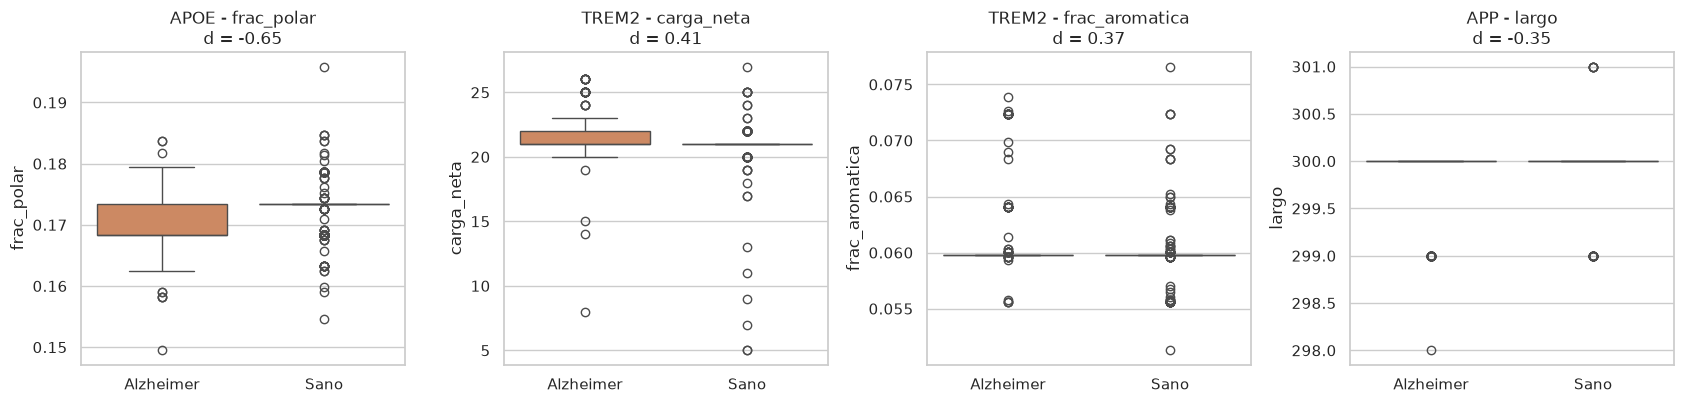

In [12]:
# Boxplots de los descriptores mas diferenciales
top = efectos.head(4)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, fila in zip(axes, top.itertuples(index=False)):
    sub = props[props["gene"] == fila.gene]
    sns.boxplot(data=sub, x="diagnostico", y=fila.descriptor, hue="diagnostico",
                palette=PALETA, legend=False, ax=ax)
    ax.set(title=f"{fila.gene} - {fila.descriptor}\nd = {fila.efecto_d:.2f}", xlabel="")
plt.tight_layout()
guardar_figura("propiedades_diferenciales")
plt.show()

---
## 7. Exportar el insumo para el notebook 04

La capa proteica se resume por paciente: numero de cambios, presencia de cambio extenso y las
propiedades de las proteinas donde se concentran las diferencias.

In [13]:
# Conteos por paciente
resumen_paciente = (clasificacion.pivot_table(index="patient_id", columns="gene",
                                              values="n_eventos", aggfunc="sum",
                                              fill_value=0)
                    .reindex(columns=GENES, fill_value=0))
resumen_paciente.columns = [f"n_cambios_prot_{g}" for g in resumen_paciente.columns]
resumen_paciente["n_cambios_prot_total"] = resumen_paciente.sum(axis=1)

extensos = (clasificacion.assign(
                extenso=lambda d: d["clase"].eq("cambio extenso (compatible con frameshift)"))
            .pivot_table(index="patient_id", columns="gene", values="extenso",
                         aggfunc="max", fill_value=0)
            .reindex(columns=GENES, fill_value=0).astype(int))
extensos.columns = [f"frameshift_{g}" for g in extensos.columns]
extensos["n_proteinas_con_frameshift"] = extensos.sum(axis=1)

# Propiedades de las proteinas con mayor senal
GENES_PROP = efectos["gene"].head(3).unique().tolist()
tabla_props = props[props["gene"].isin(GENES_PROP)].pivot_table(
    index="patient_id", columns="gene",
    values=["frac_hidrofobica", "frac_cargada", "carga_neta", "largo"])
tabla_props.columns = [f"{a}_{b}" for a, b in tabla_props.columns]

proteina_integracion = (resumen_paciente.join(extensos).join(tabla_props)
                        .reset_index(names="patient_id")
                        .merge(clinica[["patient_id", "alzheimer"]], on="patient_id"))

ruta = guardar_tabla(proteina_integracion, "proteina_para_integracion")
print("Guardado:", ruta)
print("Filas:", len(proteina_integracion), "| Columnas:", len(proteina_integracion.columns))
proteina_integracion.head()

Guardado: /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/results/tables/proteina_para_integracion.csv
Filas: 1000 | Columnas: 22


,patient_id,n_cambios_prot_APP,n_cambios_prot_PSEN1,n_cambios_prot_PSEN2,n_cambios_prot_APOE,n_cambios_prot_TREM2,n_cambios_prot_total,frameshift_APP,frameshift_PSEN1,frameshift_PSEN2,frameshift_APOE,frameshift_TREM2,n_proteinas_con_frameshift,carga_neta_APOE,carga_neta_TREM2,frac_cargada_APOE,frac_cargada_TREM2,frac_hidrofobica_APOE,frac_hidrofobica_TREM2,largo_APOE,largo_TREM2,alzheimer
0,P0001,0,1,106,1,1,109,0,0,1,0,0,1,16.0,20.0,0.183673,0.196581,0.306122,0.380342,200.0,240.0,1
1,P0002,140,0,106,3,0,249,1,0,1,0,0,2,16.0,21.0,0.184615,0.200855,0.297436,0.376068,200.0,240.0,1
2,P0003,0,4,3,0,2,9,0,0,0,0,0,0,16.0,22.0,0.183673,0.204255,0.301020,0.378723,200.0,240.0,1
3,P0004,0,2,0,3,34,39,0,0,0,0,1,1,17.0,26.0,0.188776,0.204255,0.301020,0.370213,200.0,240.0,1
4,P0005,1,0,2,2,7,12,0,0,0,0,0,0,16.0,24.0,0.183673,0.197425,0.301020,0.386266,200.0,239.0,0


---
## 8. Conclusiones del analisis proteico

1. Se compararon 5.000 secuencias proteicas contra su referencia y se detectaron **28.655
   eventos**: 28.351 sustituciones, 218 deleciones y 86 inserciones. El numero de sustituciones
   es muy superior al de SNPs en DNA (5.248) porque **los frameshift alteran cientos de
   aminoacidos a partir de un solo nucleotido perdido o ganado**.
2. Clasificacion de las secuencias: 2.362 sin cambio, 2.231 con sustituciones puntuales,
   176 con indel in-frame y **231 con cambio extenso compatible con frameshift**.
3. El reparto entre grupos es claro: el 54.4% de las secuencias de controles no tiene ningun
   cambio, frente al 33.5% en casos. Los cambios extensos aparecen en 6.3% de las secuencias
   de casos y 3.7% de las de controles.
4. **De las 14 variantes de DNA recurrentes: 10 son missense, 2 son indels in-frame y 2 producen
   frameshift.** Ninguna resulto sinonima, lo que es consistente con un dataset docente donde las
   variantes se sembraron para tener efecto visible.
5. Las dos variantes del haplotipo APOE son missense: `APOE:205:T>G` cambia C por G en la posicion
   69, y `APOE:311:C>T` cambia T por I en la posicion 104.
6. **La prediccion de frameshift se valida sola.** `PSEN2:407:GC>-` (delecion de 2 nt) y
   `TREM2:604:->TA` (insercion de 2 nt) fueron clasificadas como frameshift por no ser multiplo
   de 3, y el **100% de sus portadores** aparece con cambio extenso en el analisis proteico, hecho
   de forma independiente. En cambio `PSEN1:612:->GCT` y `APP:688:TCC>-` son multiplos de 3, se
   predijeron in-frame, y el 0% de sus portadores muestra cambio extenso.
7. Entre las propiedades, la fraccion polar de APOE es la que mas difiere entre grupos
   (d = -0.65), seguida de la carga neta (d = 0.41) y la fraccion aromatica (d = 0.37) de TREM2.
   Son efectos moderados y pequenos: **las propiedades globales de composicion diluyen el efecto
   de cambios puntuales**, porque un aminoacido distinto en 200 apenas mueve una fraccion.

### Limitaciones

- Los fragmentos sinteticos **no son secuencias codificantes canonicas**: la traduccion literal
  produce codones de parada internos, representados como X (3.2% de los residuos). Eso limita la
  interpretacion biologica de las propiedades.
- La regla adoptada para los X (excluirlos del denominador) es **una decision del grupo**. Otra
  regla razonable daria valores algo distintos, aunque el orden entre proteinas se mantendria.
- El umbral de 10% de residuos alterados para llamar "cambio extenso" tambien es una decision
  declarada, no un criterio estandar.
- Las propiedades son descriptores de composicion. No dicen nada sobre estructura, estabilidad ni
  funcion, y la guia explicitamente no lo pide.
- La correspondencia posicion nucleotido a posicion aminoacido supone traduccion en marco 1 sin
  intrones, que es como se construyo el dataset pero no como funciona un gen real.
- Todo lo observado es **asociacion descriptiva** en datos sinteticos.

### Preguntas de defensa que este notebook deja cubiertas

| Pregunta | Donde esta la respuesta |
|---|---|
| Si una variante de DNA no cambia el aminoacido, que esperarian ver en proteina? | Seccion 5 (ninguna resulto sinonima, pero el criterio esta implementado) |
| Como identificaron un cambio aminoacidico? | Seccion 3 |
| Que hicieron con los residuos X? | Seccion 2 (regla declarada y aplicada a todos) |
| Que es un frameshift y como lo detectaron? | Secciones 4 y 5, con validacion cruzada en la conclusion 6 |
| Por que un indel de 3 nucleotidos no produce frameshift? | Seccion 5 (multiplo de 3 = un aminoacido completo) |
| Por que hay muchas mas sustituciones en proteina que SNPs en DNA? | Conclusion 1 (efecto de los frameshift) |
| Por que las propiedades muestran efectos tan pequenos? | Conclusion 7 (dilucion de cambios puntuales) |
| Que no pueden concluir de estas propiedades? | Seccion 8, limitaciones |
